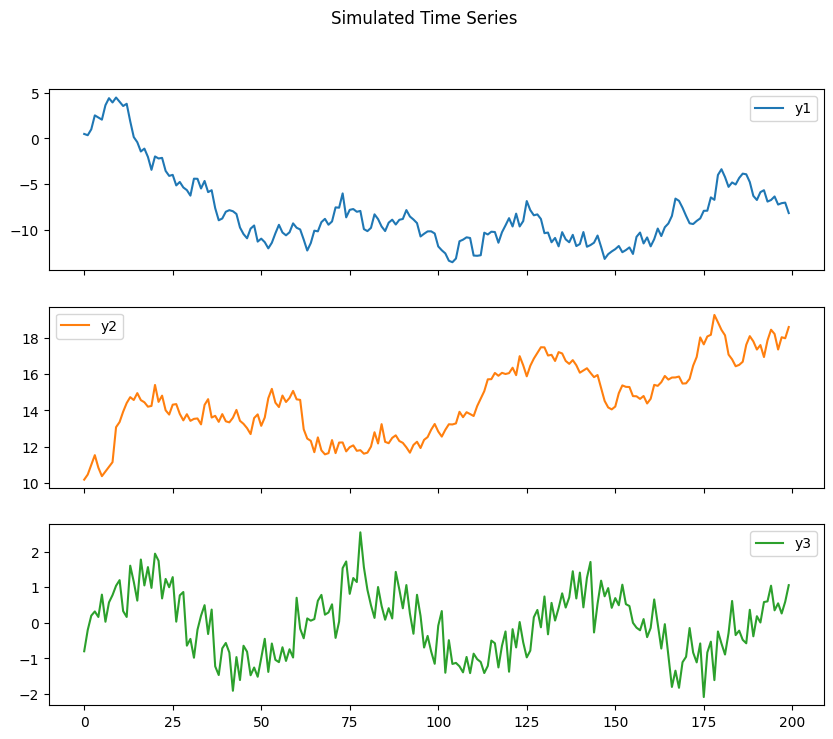

ADF Test for y1:
Test Statistic: -2.3073
P-Value: 0.1696
y1 has a unit root (non-stationary).

ADF Test for y2:
Test Statistic: -1.8198
P-Value: 0.3707
y2 has a unit root (non-stationary).

ADF Test for y3:
Test Statistic: -4.4490
P-Value: 0.0002
y3 is stationary.

ADF Test for Residuals of y1 ~ y2:
Test Statistic: -2.1708
P-Value: 0.2170
Residuals of y1 ~ y2 has a unit root (non-stationary).

Engle-Granger Cointegration Test:
Test Statistic: -2.1745
P-Value: 0.4376
Critical Values: [-3.95232129 -3.36700631 -3.06583125]
y1 and y2 are not cointegrated.

ADF Test for Residuals of y1 ~ y2:
Test Statistic: -2.1708
P-Value: 0.2170
Residuals of y1 ~ y2 has a unit root (non-stationary).

Engle-Granger Cointegration Test:
Test Statistic: -2.1745
P-Value: 0.4376
Critical Values: [-3.95232129 -3.36700631 -3.06583125]
y1 and y2 are not cointegrated.



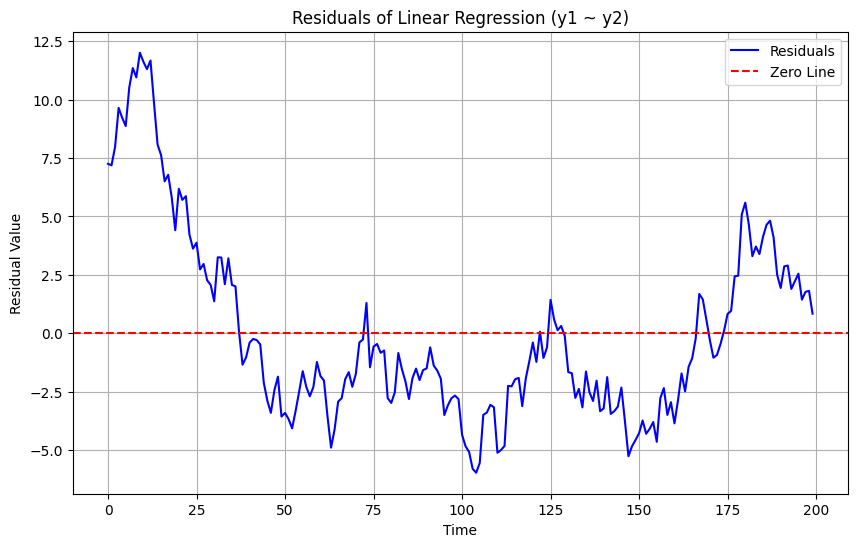

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Simulate time series data
np.random.seed(42)
n = 200
t = np.arange(n)
# Non-stationary series with a unit root
y1 = np.cumsum(np.random.normal(size=n))
# Another non-stationary series with a unit root
y2 = 0.5 * np.cumsum(np.random.normal(size=n)) + 10
# Stationary series
y3 = np.sin(t / 10) + np.random.normal(scale=0.5, size=n)
# Create a DataFrame
data = pd.DataFrame({"y1": y1, "y2": y2, "y3": y3})
# Plot the series
data.plot(subplots=True, figsize=(10, 8), title="Simulated Time Series")
plt.show()

from statsmodels.tsa.stattools import adfuller
# Function to perform ADF test
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"{name} has a unit root (non-stationary).\n")
    else:
        print(f"{name} is stationary.\n")
# Perform ADF test
adf_test(data["y1"], "y1")
adf_test(data["y2"], "y2")
adf_test(data["y3"], "y3")

from statsmodels.api import OLS
from statsmodels.tsa.stattools import coint
from statsmodels.api import add_constant

# Add constant and perform linear regression
X = add_constant(data["y2"])
model = OLS(data["y1"], X).fit()
residuals = model.resid

# Test residuals for stationarity (cointegration)
adf_test(residuals, "Residuals of y1 ~ y2")

# Alternatively, use the coint function for direct testing
coint_stat, p_value, critical_values = coint(data["y1"], data["y2"])
print("Engle-Granger Cointegration Test:")
print(f"Test Statistic: {coint_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Critical Values: {critical_values}")
if p_value < 0.05:
    print("y1 and y2 are cointegrated.\n")
else:
    print("y1 and y2 are not cointegrated.\n")
# Test residuals for stationarity (cointegration)
adf_test(residuals, "Residuals of y1 ~ y2")
# Alternatively, use the coint function for direct testing
coint_stat, p_value, critical_values = coint(data["y1"], data["y2"])
print("Engle-Granger Cointegration Test:")
print(f"Test Statistic: {coint_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Critical Values: {critical_values}")
if p_value < 0.05:
    print("y1 and y2 are cointegrated.\n")
else:
    print("y1 and y2 are not cointegrated.\n")

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals, label="Residuals", color="blue")
plt.axhline(0, linestyle="--", color="red", label="Zero Line")
plt.title("Residuals of Linear Regression (y1 ~ y2)")
plt.xlabel("Time")
plt.ylabel("Residual Value")
plt.legend()
plt.grid()
plt.show()

[*********************100%***********************]  1 of 1 completed


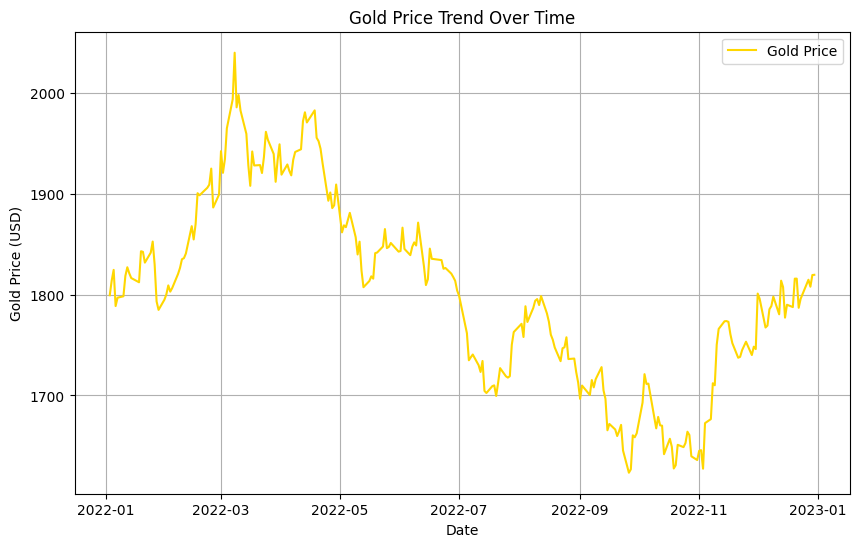

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
# Use the correct ticker symbol for gold, for example, 'GC=F' (Gold Futures)
gold_ticker = 'GC=F'
# Fetch historical data
gold_data = yf.download(gold_ticker, start="2022-01-01", end="2023-01-01")
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(gold_data['Close'], label='Gold Price', color='gold')
plt.title('Gold Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


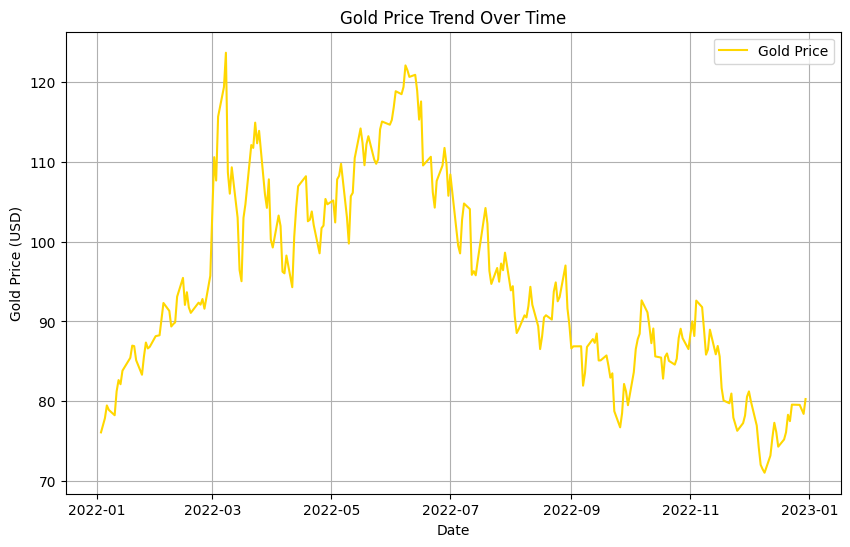

In [5]:
import yfinance as yf
import matplotlib.pyplot as plt
# Use the correct ticker symbol for gold, for example, 'GC=F' (Gold Futures)
gold_ticker = 'CL=F'
# Fetch historical data
gold_data = yf.download(gold_ticker, start="2022-01-01", end="2023-01-01")
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(gold_data['Close'], label='Gold Price', color='gold')
plt.title('Gold Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Gold data shape: (1029, 5)
Oil data shape: (1029, 5)

Merged data shape: (1029, 2)

First few rows of merged data:
                   Gold        Oil
Date                              
2020-01-02  1524.500000  61.180000
2020-01-03  1549.199951  63.049999
2020-01-06  1566.199951  63.270000
2020-01-07  1571.800049  62.700001
2020-01-08  1557.400024  59.610001


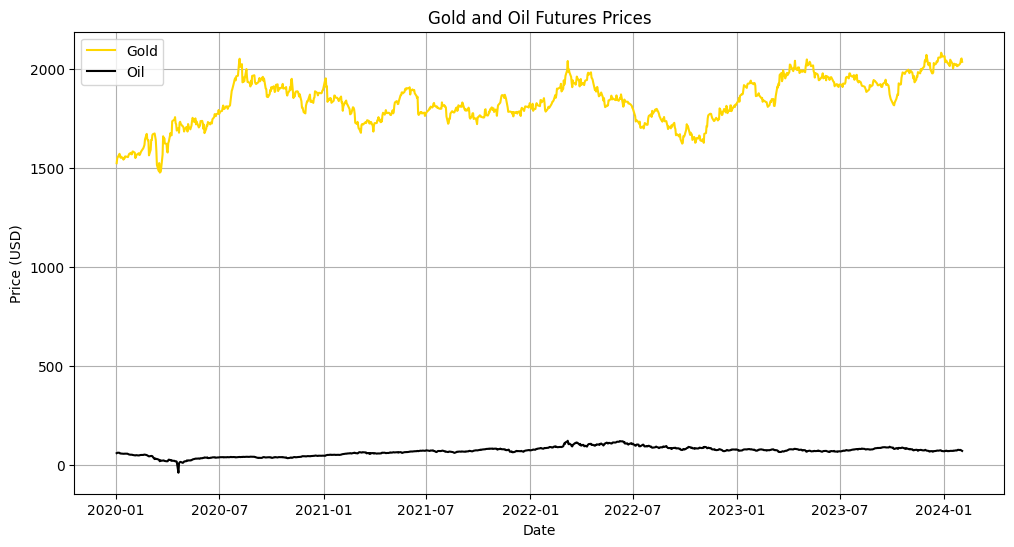

ADF Test for Gold:
Test Statistic: -2.5356
P-Value: 0.1070
Gold has a unit root (non-stationary).

ADF Test for Oil:
Test Statistic: -1.4773
P-Value: 0.5447
Oil has a unit root (non-stationary).


Regression Results:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1744.9552     11.752    148.482      0.000    1721.895    1768.016
Oil            1.2554      0.160      7.825      0.000       0.941       1.570
ADF Test for Residuals of Gold ~ Oil:
Test Statistic: -2.8125
P-Value: 0.0565
Residuals of Gold ~ Oil has a unit root (non-stationary).


Engle-Granger Cointegration Test:
Test Statistic: -2.8138
P-Value: 0.1613
Critical Values:
1%: -3.9071
5%: -3.3421
10%: -3.0486
Gold and Oil are not cointegrated.



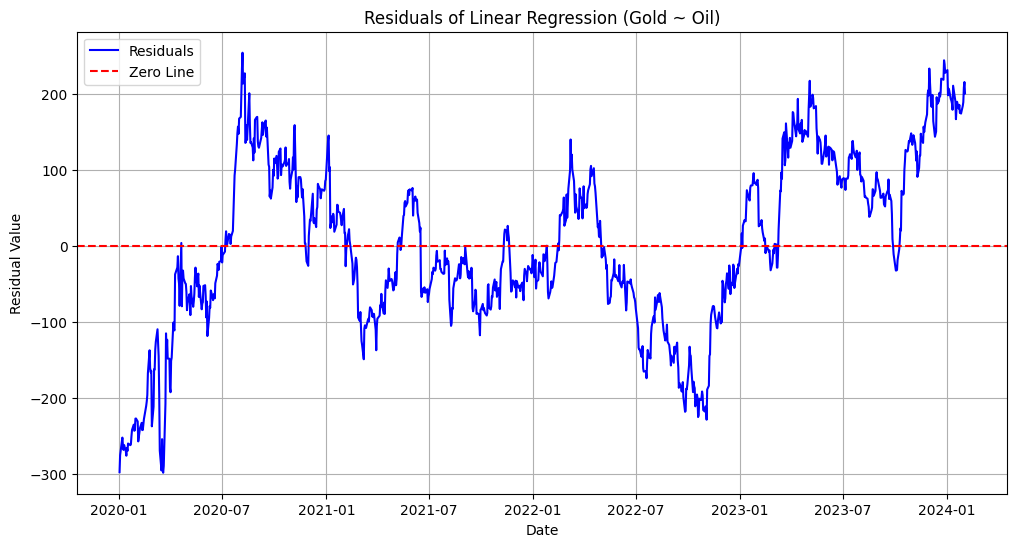

In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import adfuller, coint

# Download data
def get_data(start_date="2020-01-01", end_date="2024-02-04"):
    # Download data
    print("Downloading Gold data...")
    gold = yf.download('GC=F', start=start_date, end=end_date)
    print("Downloading Oil data...")
    oil = yf.download('CL=F', start=start_date, end=end_date)

    print("\nGold data shape:", gold.shape)
    print("Oil data shape:", oil.shape)

    # Check if data is empty
    if gold.empty or oil.empty:
        raise ValueError("No data retrieved for one or both symbols")

    # Create DataFrame with close prices
    merged_data = pd.merge(
        gold['Close'],
        oil['Close'],
        left_index=True,
        right_index=True,
        how='inner',
        suffixes=('_Gold', '_Oil')
    )

    # Rename columns
    merged_data.columns = ['Gold', 'Oil']

    print("\nMerged data shape:", merged_data.shape)
    print("\nFirst few rows of merged data:")
    print(merged_data.head())

    return merged_data

# Function to perform ADF test
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"{name} has a unit root (non-stationary).\n")
    else:
        print(f"{name} is stationary.\n")

try:
    # Get the data
    data = get_data()

    # Plot the series
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Gold'], label='Gold', color='gold')
    plt.plot(data.index, data['Oil'], label='Oil', color='black')
    plt.title('Gold and Oil Futures Prices')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Test for stationarity
    adf_test(data['Gold'], 'Gold')
    adf_test(data['Oil'], 'Oil')

    # Perform linear regression with constant
    X = add_constant(data['Oil'])
    model = OLS(data['Gold'], X).fit()
    residuals = model.resid

    # Print regression results
    print("\nRegression Results:")
    print(model.summary().tables[1])

    # Test residuals for stationarity (cointegration)
    adf_test(residuals, "Residuals of Gold ~ Oil")

    # Use coint function for direct testing
    coint_stat, p_value, critical_values = coint(data['Gold'], data['Oil'])
    print("\nEngle-Granger Cointegration Test:")
    print(f"Test Statistic: {coint_stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    print("Critical Values:")
    print(f"1%: {critical_values[0]:.4f}")
    print(f"5%: {critical_values[1]:.4f}")
    print(f"10%: {critical_values[2]:.4f}")
    if p_value < 0.05:
        print("Gold and Oil are cointegrated.\n")
    else:
        print("Gold and Oil are not cointegrated.\n")

    # Plot the residuals
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, residuals, label='Residuals', color='blue')
    plt.axhline(0, linestyle='--', color='red', label='Zero Line')
    plt.title('Residuals of Linear Regression (Gold ~ Oil)')
    plt.xlabel('Date')
    plt.ylabel('Residual Value')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"An error occurred: {str(e)}")
    # Print more detailed error information
    import traceback
    traceback.print_exc()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Original data first few rows:
                   Gold        Oil
Date                              
2020-01-02  1524.500000  61.180000
2020-01-03  1549.199951  63.049999
2020-01-06  1566.199951  63.270000
2020-01-07  1571.800049  62.700001
2020-01-08  1557.400024  59.610001

Scaled data first few rows:
                Gold       Oil
Date                          
2020-01-02 -1.515269 -0.493110
2020-01-03 -1.428300 -0.399658
2020-01-06 -1.368442 -0.388663
2020-01-07 -1.348724 -0.417149
2020-01-08 -1.399427 -0.571571


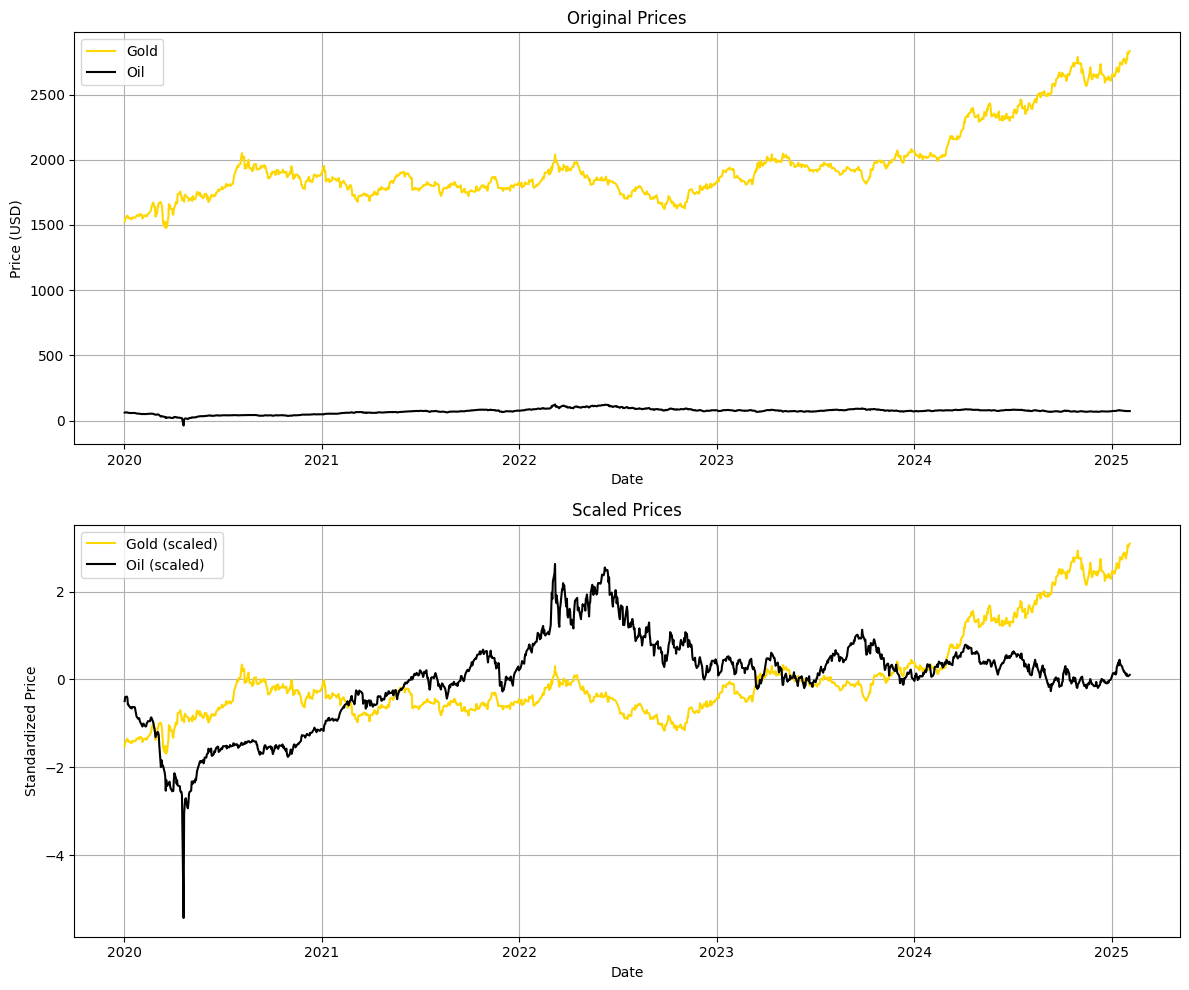

ADF Test for Scaled Gold:
Test Statistic: 0.3642
P-Value: 0.9801
Scaled Gold has a unit root (non-stationary).

ADF Test for Scaled Oil:
Test Statistic: -1.7165
P-Value: 0.4226
Scaled Oil has a unit root (non-stationary).


Regression Results:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.439e-16      0.028  -8.85e-15      1.000      -0.054       0.054
Oil            0.1663      0.028      6.031      0.000       0.112       0.220
ADF Test for Residuals of Gold ~ Oil:
Test Statistic: 0.4576
P-Value: 0.9835
Residuals of Gold ~ Oil has a unit root (non-stationary).


Engle-Granger Cointegration Test:
Test Statistic: 0.4478
P-Value: 0.9923
Critical Values:
1%: -3.9050
5%: -3.3409
10%: -3.0478
Gold and Oil are not cointegrated.



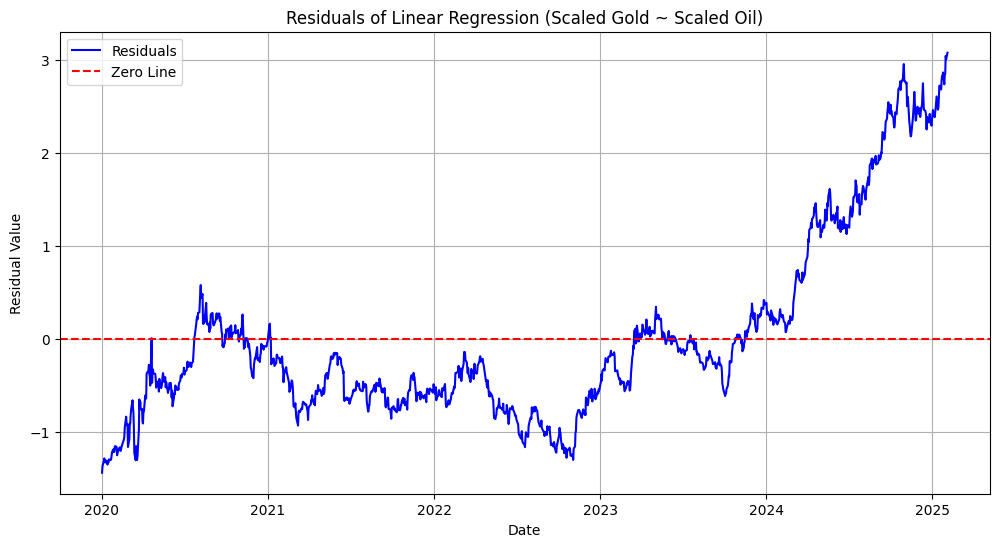

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import adfuller, coint
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def get_data(start_date="2020-01-01", end_date="2025-02-04", scaling_method='standard'):
    # Download data
    print("Downloading Gold data...")
    gold = yf.download('GC=F', start=start_date, end=end_date)
    print("Downloading Oil data...")
    oil = yf.download('CL=F', start=start_date, end=end_date)

    # Create DataFrame with close prices
    merged_data = pd.merge(
        gold['Close'],
        oil['Close'],
        left_index=True,
        right_index=True,
        how='inner',
        suffixes=('_Gold', '_Oil')
    )

    # Rename columns
    merged_data.columns = ['Gold', 'Oil']

    # Apply scaling
    if scaling_method == 'standard':
        scaler = StandardScaler()
        scaled_data = pd.DataFrame(
            scaler.fit_transform(merged_data),
            columns=merged_data.columns,
            index=merged_data.index
        )
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
        scaled_data = pd.DataFrame(
            scaler.fit_transform(merged_data),
            columns=merged_data.columns,
            index=merged_data.index
        )
    else:
        raise ValueError("Invalid scaling method. Use 'standard' or 'minmax'")

    print("\nOriginal data first few rows:")
    print(merged_data.head())
    print("\nScaled data first few rows:")
    print(scaled_data.head())

    return scaled_data, merged_data

def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"{name} has a unit root (non-stationary).\n")
    else:
        print(f"{name} is stationary.\n")

try:
    # Get both original and scaled data
    scaled_data, original_data = get_data(scaling_method='standard')

    # Plot both original and scaled series
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Original data
    ax1.plot(original_data.index, original_data['Gold'], label='Gold', color='gold')
    ax1.plot(original_data.index, original_data['Oil'], label='Oil', color='black')
    ax1.set_title('Original Prices')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (USD)')
    ax1.legend()
    ax1.grid(True)

    # Scaled data
    ax2.plot(scaled_data.index, scaled_data['Gold'], label='Gold (scaled)', color='gold')
    ax2.plot(scaled_data.index, scaled_data['Oil'], label='Oil (scaled)', color='black')
    ax2.set_title('Scaled Prices')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Standardized Price')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Test for stationarity
    adf_test(scaled_data['Gold'], 'Scaled Gold')
    adf_test(scaled_data['Oil'], 'Scaled Oil')

    # Perform linear regression with constant
    X = add_constant(scaled_data['Oil'])
    model = OLS(scaled_data['Gold'], X).fit()
    residuals = model.resid

    # Print regression results
    print("\nRegression Results:")
    print(model.summary().tables[1])

    # Test residuals for stationarity (cointegration)
    adf_test(residuals, "Residuals of Gold ~ Oil")

    # Use coint function for direct testing
    coint_stat, p_value, critical_values = coint(scaled_data['Gold'], scaled_data['Oil'])
    print("\nEngle-Granger Cointegration Test:")
    print(f"Test Statistic: {coint_stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    print("Critical Values:")
    print(f"1%: {critical_values[0]:.4f}")
    print(f"5%: {critical_values[1]:.4f}")
    print(f"10%: {critical_values[2]:.4f}")
    if p_value < 0.05:
        print("Gold and Oil are cointegrated.\n")
    else:
        print("Gold and Oil are not cointegrated.\n")

    # Plot the residuals
    plt.figure(figsize=(12, 6))
    plt.plot(scaled_data.index, residuals, label='Residuals', color='blue')
    plt.axhline(0, linestyle='--', color='red', label='Zero Line')
    plt.title('Residuals of Linear Regression (Scaled Gold ~ Scaled Oil)')
    plt.xlabel('Date')
    plt.ylabel('Residual Value')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"An error occurred: {str(e)}")
    import traceback
    traceback.print_exc()
